In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Business Understanding


In [83]:
df = pd.read_csv('/content/drive/MyDrive/bootcamp/hari_37/bank_churn_data.csv')

In [84]:
df.head().T

,0,1,2,3,4
user_id,768805383,818770008,713982108,769911858,709106358
attrition_flag,Existing Customer,Existing Customer,Existing Customer,Existing Customer,Existing Customer
customer_age,45,49,51,40,40
gender,M,F,M,F,M
dependent_count,3,5,3,4,3
education_level,High School,Graduate,Graduate,High School,Uneducated
marital_status,Married,Single,Married,Unknown,Married
income_category,$60K - $80K,Less than $40K,$80K - $120K,Less than $40K,$60K - $80K
card_category,Blue,Blue,Blue,Blue,Blue
months_on_book,39,44,36,34,21


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

## a. menghitung churn rate

In [86]:
df['attrition_flag'].unique()
churn_rate = (df['attrition_flag'] == 'Attrited Customer').mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 16.07%


## b. Estimasikan dampak churn terhadap revenue menggunakan variabel transaksi yang tersedia.


In [87]:
# memisahkan data churn dan tidak churn
churn = df[df['attrition_flag'] == 'Attrited Customer']
no_churn = df[df['attrition_flag'] == 'Existing Customer']

In [88]:
revenue_loss = churn['total_trans_amt'].sum()

print(f'estimasi revenue loss : {revenue_loss}')
# di asumsikan jika customer churn maka transaksi mereka juga hilang

estimasi revenue loss : 5035607


In [89]:
# rata rata revenue per churn customer
avg_churn_revenue = churn['total_trans_amt'].mean()
print(f'rata rata revenue per churn customer {avg_churn_revenue}')

rata rata revenue per churn customer 3095.025814382299


In [90]:
# membandingkan dengan customer yang aktif
avg_no_churn_customer = no_churn['total_trans_amt'].mean()

print(f'no churn customer: {avg_no_churn_customer:.2f}')
print(f'churn customer {avg_churn_revenue:.2f}')

no churn customer: 4654.66
churn customer 3095.03


terlihat bahwa sebelum churn, aktivitas customer sudah menurun

maka kemungkinan mereka churn karena
transaksi turun -> jarang pakai -> churn

Estimasi menunjukkan bahwa churn pelanggan memberikan dampak yang cukup signifikan terhadap revenue perusahaan. Dari hasil perhitungan, total estimasi revenue yang hilang akibat pelanggan yang churn mencapai sekitar 5,035,607, dengan rata-rata revenue per pelanggan churn sebesar 3,095.03. Hal ini menunjukkan bahwa setiap pelanggan yang berhenti menggunakan layanan membawa serta nilai transaksi yang cukup besar. Kehilangan pelanggan tidak hanya berdampak pada berkurangnya pendapatan saat ini, tetapi juga menghilangkan potensi transaksi yang seharusnya dapat terjadi di masa mendatang.

## c. menentukan metrik yang cocok
1. karena kasus nya churn dan tidak churn yang dimana variable nya terdapat 1 dan 0 saja maka akan di pastikan model predictif menggunakan klasifikasi
2. karena model akan menggunakan klasifikasi metrik yang di gunakan antara lain
- recall
- f1_score
- roc_auc

- Recall:
Recall digunakan karena dalam kasus churn tujuan utama model adalah mengidentifikasi sebanyak mungkin pelanggan yang benar-benar berpotensi churn. Jika model gagal mendeteksi pelanggan yang sebenarnya akan churn (false negative), maka perusahaan tidak dapat melakukan strategi retensi seperti pemberian promo atau peningkatan layanan. Hal ini dapat menyebabkan kehilangan pelanggan dan penurunan revenue, sehingga recall menjadi metrik penting untuk memastikan sebagian besar pelanggan berisiko churn dapat terdeteksi.

- F1-score:
F1-score digunakan karena metrik ini memberikan keseimbangan antara precision dan recall. Jika hanya menggunakan recall, model bisa saja memprediksi terlalu banyak pelanggan sebagai churn sehingga menghasilkan banyak false positive. Dengan F1-score, performa model dapat dinilai secara lebih seimbang karena mempertimbangkan kemampuan model dalam mendeteksi churn sekaligus menjaga agar prediksi churn tidak terlalu berlebihan.

- ROC-AUC:
ROC-AUC digunakan untuk mengukur kemampuan model dalam membedakan antara pelanggan yang churn dan yang tidak churn berdasarkan probabilitas prediksi yang dihasilkan model. Metrik ini tidak hanya melihat hasil klasifikasi akhir, tetapi juga menilai seberapa baik model memberi skor risiko yang lebih tinggi pada pelanggan yang benar-benar churn. Nilai ROC-AUC yang tinggi menunjukkan bahwa model memiliki kemampuan yang baik dalam memisahkan kedua kelas tersebut, sehingga model lebih dapat diandalkan dalam mengidentifikasi pelanggan dengan risiko churn yang tinggi.

## D. resiko bisnis jika model salah memprediksi churn

jika model salah prediksi model maka hal paling buruk yang akan terjadi kesalahan dalam memberikan tindakan jika model 80% prediksi churn padahal tidak sebesar itu maka perusahaan bisa mengeluarkan biaya yang terlalu besar karena over dalam melakukan tindakan untuk mencegah customer churn

# 2. Exploratory Data Analysis (EDA) Analisis churn rate berdasarkan variabel kategorikal.

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

## a. churn berdasarkan variable

In [92]:
# berdasarkan age

df_eda = df.copy()

df_eda['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0,30,40,50,100],
    labels=['<30','30-40','40-50','>50']
)

age_churn = df_eda.groupby('age_group')['attrition_flag'].value_counts(normalize=True)

/tmp/ipykernel_188/3292104384.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df_eda.groupby('age_group')['attrition_flag'].value_counts(normalize=True)


In [93]:
age_churn

age_group  attrition_flag   
<30        Existing Customer    0.879245
           Attrited Customer    0.120755
30-40      Existing Customer    0.854597
           Attrited Customer    0.145403
40-50      Existing Customer    0.832545
           Attrited Customer    0.167455
>50        Existing Customer    0.835608
           Attrited Customer    0.164392
Name: proportion, dtype: float64

- churn meningkat seiring bertambahnya usia
- puncak terjadi di umur 40-50
insight : customer usia 40 - 50 tahun memiliki tingkat churn tertinggi (~16.7%), sedangkan paling rendah berada di umur 30 tahun ke bawah, menunjukan bahwa churn lebih sering terjadi di umur pertangahan dari pada di umur paling rendah dan di umur paling tinggi (>50)

In [94]:
df_eda["tenure_group"] = pd.cut(
    df_eda["months_on_book"],
    bins=[0,24,36,48,100],
    labels=["<2yr","2-3yr","3-4yr",">4yr"]
)

tenure_churn = df_eda.groupby("tenure_group")["attrition_flag"].value_counts(normalize=True)

/tmp/ipykernel_188/15629589.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df_eda.groupby("tenure_group")["attrition_flag"].value_counts(normalize=True)


In [95]:
tenure_churn

tenure_group  attrition_flag   
<2yr          Existing Customer    0.851240
              Attrited Customer    0.148760
2-3yr         Existing Customer    0.839240
              Attrited Customer    0.160760
3-4yr         Existing Customer    0.838167
              Attrited Customer    0.161833
>4yr          Existing Customer    0.830534
              Attrited Customer    0.169466
Name: proportion, dtype: float64

insight : churn tertinggi terjadi di tahun < 2 tahun hal itu di sebabkan karena customer masih mencoba coba produk yang di langganankan nya

In [96]:
# churn berdasarkan contact count

df_eda.groupby('contacts_count_12_mon')['attrition_flag'].value_counts(normalize=True)

contacts_count_12_mon  attrition_flag   
0                      Existing Customer    0.982456
                       Attrited Customer    0.017544
1                      Existing Customer    0.927952
                       Attrited Customer    0.072048
2                      Existing Customer    0.875116
                       Attrited Customer    0.124884
3                      Existing Customer    0.798521
                       Attrited Customer    0.201479
4                      Existing Customer    0.773707
                       Attrited Customer    0.226293
5                      Existing Customer    0.664773
                       Attrited Customer    0.335227
6                      Attrited Customer    1.000000
Name: proportion, dtype: float64

insight : Customer dengan frekuensi kontak yang lebih tinggi dalam 12 bulan terakhir menunjukkan tingkat churn yang lebih besar. Tingkat churn meningkat secara konsisten dari sekitar 1.7% pada customer yang tidak pernah melakukan kontak hingga lebih dari 33% pada customer yang melakukan kontak sebanyak lima kali. Hal ini menunjukkan bahwa frekuensi interaksi dengan pihak bank kemungkinan mencerminkan adanya masalah atau ketidakpuasan terhadap layanan, sehingga meningkatkan risiko pelanggan untuk berhenti menggunakan layanan tersebut.

## b. Identifikasi segmen customer dengan risiko churn tertinggi.

segmen tertinggi di sebabkan oleh seberapa sering customer contact dengan pihak langganan menunjukan semakin sering semakin tinggi tingkat churn

# 3. feature engineering

## a. Lakukan encoding pada fitur kategorikal.


In [97]:
for i in df.select_dtypes(exclude='number').columns:
    print(f'nilai unique dari {i} : {df[i].unique()}')

nilai unique dari attrition_flag : ['Existing Customer' 'Attrited Customer']
nilai unique dari gender : ['M' 'F']
nilai unique dari education_level : ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
nilai unique dari marital_status : ['Married' 'Single' 'Unknown' 'Divorced']
nilai unique dari income_category : ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
nilai unique dari card_category : ['Blue' 'Gold' 'Silver' 'Platinum']


In [98]:
# fitur attrition_flag
df['attrition_flag'] = df['attrition_flag'].map({'Existing Customer':0,'Attrited Customer':1}).astype(int)

In [99]:
#gender
df['gender'] = df['gender'].map({'M':0,'F':1})

In [100]:
df = pd.get_dummies(df, columns=['education_level'], drop_first=True, dtype=int)

In [101]:
df = pd.get_dummies(df, columns=['marital_status'], drop_first=True, dtype=int)

In [102]:
df['income_category'] = df['income_category'].map({'Unknown':0,'Less than $40K':1,'$40K - $60K':2,'$60K - $80K':3,'$80K - $120K':4,'$120K +':5}).astype(int)

In [103]:
df['card_category'] = df['card_category'].map({'Blue':1,'Silver':2,'Gold':3,'Platinum':4}).astype(int)

## b. Lakukan transformasi fitur yang diperlukan untuk meningkatkan kualitas model.

In [104]:
# menghapus fitur user_id
df = df.drop('user_id', axis=1)

In [105]:
# standarisasi fitur dengan nlai continue
from sklearn.preprocessing import StandardScaler

num_cols = [
    'customer_age',
    'credit_limit',
    'avg_open_to_buy',
    'total_trans_amt',
    'total_trans_ct',
    'avg_utilization_ratio',
    'total_amt_chng_q4_q1',
    'total_ct_chng_q4_q1'
]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

## c. Jelaskan alasan setiap langkah preprocessing yang dilakukan.

1. Mengubah variabel attrition_flag menjadi nilai 0 dan 1, di mana nilai 0 merepresentasikan pelanggan yang tidak melakukan churn (Existing Customer) dan nilai 1 merepresentasikan pelanggan yang melakukan churn (Attrited Customer). Transformasi ini dilakukan karena sebagian besar algoritma machine learning membutuhkan target variabel dalam bentuk numerik agar dapat diproses selama proses pelatihan model.

2. Mengubah variabel gender menjadi nilai 0 dan 1, karena fitur ini hanya memiliki dua kategori yaitu Male dan Female. Oleh karena itu, proses encoding biner dapat digunakan untuk merepresentasikan kedua kategori tersebut ke dalam bentuk numerik sehingga dapat digunakan oleh model machine learning.

3. Melakukan One-Hot Encoding pada fitur marital_status dan education_level, karena kedua fitur tersebut merupakan variabel kategorikal yang tidak memiliki hubungan urutan yang jelas. Jika kategori pada fitur tersebut langsung diubah menjadi angka menggunakan metode label encoding, model dapat menginterpretasikan bahwa kategori dengan angka yang lebih besar memiliki hubungan atau tingkat yang lebih tinggi dibandingkan kategori lainnya. Hal ini dapat menyebabkan model menangkap hubungan yang sebenarnya tidak ada pada data. Meskipun pada fitur education_level terlihat seperti memiliki urutan tingkat pendidikan, hubungan tersebut tidak selalu linear terhadap kemungkinan churn, sehingga lebih aman direpresentasikan menggunakan One-Hot Encoding agar setiap kategori diperlakukan secara independen oleh model.

4. melakukan ordinal encoding secara manual kepada fitur income_category dan card_category karena 2 fitur merupakan fitur yang merepresentasikan tingkatan manusia secara eksplisit

5. melakukan drop terhadap fitur user_id karena user_id tidak akan terlalu berguna untuk prediksi

6. melakukan standarisasi pada fitur kontinue Feature scaling dengan StandardScaler dilakukan untuk menormalkan skala nilai pada fitur numerik sehingga setiap fitur memiliki distribusi yang lebih sebanding. Dalam sebuah dataset sering terdapat fitur yang memiliki rentang nilai yang sangat berbeda. Sebagai contoh, variabel seperti credit_limit dapat memiliki nilai hingga puluhan ribu, sedangkan variabel seperti avg_utilization_ratio hanya berada pada rentang 0 hingga 1. Perbedaan skala yang terlalu besar ini dapat menyebabkan fitur dengan nilai yang lebih besar terlihat lebih dominan dibandingkan fitur lain, meskipun belum tentu memiliki pengaruh yang lebih penting terhadap target.

# Pemodelan Machine Learning Gunakan minimal dua algoritma klasifikasi untuk membangun model churn.

In [106]:
!pip install optuna

In [117]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import optuna
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [108]:
# memisahkan fitur dan target
X = df.drop('attrition_flag', axis=1)
y = df['attrition_flag']

In [109]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## a. Terapkan teknik validasi yang sesuai. (menggunakan optuna sekalian mencari hyper parameter terbaik)


In [110]:
def objective_rf(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()

    return score


study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=10)

print("Best RF Params:", study_rf.best_params)

[I 2026-03-10 06:23:24,150] A new study created in memory with name: no-name-2bf1884a-bd42-4604-85cf-82c9e3f0dc1d
[I 2026-03-10 06:24:02,514] Trial 0 finished with value: 0.9232406806762347 and parameters: {'n_estimators': 286, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9232406806762347.
[I 2026-03-10 06:24:19,909] Trial 1 finished with value: 0.9211392399300447 and parameters: {'n_estimators': 228, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9232406806762347.
[I 2026-03-10 06:24:40,506] Trial 2 finished with value: 0.9209411087360853 and parameters: {'n_estimators': 244, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9232406806762347.
[I 2026-03-10 06:25:03,896] Trial 3 finished with value: 0.922678435444022 and parameters: {'n_estimators': 261, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 0 with value: 

Best RF Params: {'n_estimators': 480, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 1}


In [112]:
def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1),
        "gamma": trial.suggest_float("gamma", 0, 5)
    }

    model = XGBClassifier(
        **params,
        random_state=42
    )

    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()

    return score


study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=10)

print("Best XGB Params:", study_xgb.best_params)

[I 2026-03-10 06:29:00,542] A new study created in memory with name: no-name-331c4f10-8d0b-4898-a568-56aa1cb71f1e
[I 2026-03-10 06:29:03,800] Trial 0 finished with value: 0.9329671698636982 and parameters: {'n_estimators': 341, 'max_depth': 9, 'learning_rate': 0.048928419901428086, 'subsample': 0.7753760097187632, 'colsample_bytree': 0.8770201240430362, 'gamma': 1.6877415140634295}. Best is trial 0 with value: 0.9329671698636982.
[I 2026-03-10 06:29:08,717] Trial 1 finished with value: 0.8996261210893041 and parameters: {'n_estimators': 251, 'max_depth': 3, 'learning_rate': 0.15808936762050277, 'subsample': 0.9381773496105272, 'colsample_bytree': 0.7542741003514818, 'gamma': 0.45455097054446947}. Best is trial 0 with value: 0.9329671698636982.
[I 2026-03-10 06:29:10,529] Trial 2 finished with value: 0.9358371684756961 and parameters: {'n_estimators': 455, 'max_depth': 7, 'learning_rate': 0.17222928666947643, 'subsample': 0.9737685928667932, 'colsample_bytree': 0.7243927760861606, 'gamm

Best XGB Params: {'n_estimators': 455, 'max_depth': 7, 'learning_rate': 0.17222928666947643, 'subsample': 0.9737685928667932, 'colsample_bytree': 0.7243927760861606, 'gamma': 3.669299271585161}


In [113]:
## trainig model dengan hyperparameter terbaik
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)

best_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, n_estimators=480, random_state=42)

In [116]:
## training model Xgboost dengan hyperparamter terbaik
best_xg = XGBClassifier(**study_xgb.best_params, random_state=42)

best_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7243927760861606, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=3.669299271585161, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.17222928666947643,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=455, n_jobs=None,
              num_parallel_tree=None, ...)

## b. Bandingkan performa model dengan baseline sederhana.


In [124]:
best_rf.score(X_test, y_test)

0.9432379072063178

In [125]:
best_xg.score(X_test, y_test)

0.9624876604146101

dengan pendekatan baseline sederhana model terbaik ada di XGBoost karena memiliki score yang lebih tinggi di bandingkan RandomForest

In [119]:
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
y_prob_xg = best_xg.predict_proba(X_test)[:,1]

y_pred_rf = best_rf.predict(X_test)
y_pred_xg = best_xg.predict(X_test)

In [120]:
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

recall_xg = recall_score(y_test, y_pred_xg)
f1_xg = f1_score(y_test, y_pred_xg)
roc_xg = roc_auc_score(y_test, y_prob_xg)

In [123]:
hasil_model = pd.DataFrame({
    "Recall": [recall_rf, recall_xg],
    "F1_score": [f1_rf, f1_xg],
    "ROC_AUC": [roc_rf, roc_xg]
}, index=["Random Forest", "XGBoost"])

hasil_model

,Recall,F1_score,ROC_AUC
Random Forest,0.697248,0.798599,0.986124
XGBoost,0.844037,0.878981,0.991544


## c. Pilih satu model terbaik berdasarkan hasil evaluasi dan jelaskan alasan pemilihannya.

dan dengan hasil yang lebih tajam dan lebih eksplisit di dapatkan
model terbaik : XGBoost
1. Recall lebih tinggi
Recall XGBoost = 0.844, sedangkan Random Forest = 0.697.
Artinya XGBoost mampu mendeteksi lebih banyak pelanggan yang benar-benar akan churn. Dalam konteks bisnis churn, ini sangat penting karena semakin banyak pelanggan churn yang terdeteksi, semakin besar peluang perusahaan melakukan strategi retensi.

2. F1-score lebih tinggi
F1-score XGBoost = 0.879, lebih tinggi dibanding Random Forest = 0.799. Ini menunjukkan bahwa XGBoost memiliki keseimbangan yang lebih baik antara precision dan recall, sehingga prediksi churn yang dihasilkan lebih akurat dan stabil.

3. ROC-AUC lebih tinggi
ROC-AUC XGBoost = 0.991, sedangkan Random Forest = 0.986. Hal ini menunjukkan bahwa XGBoost memiliki kemampuan yang sedikit lebih baik dalam membedakan antara pelanggan yang churn dan yang tidak churn berdasarkan probabilitas prediksi.

# Evaluasi Model

In [135]:
model = best_xg
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

## a. confusion matriks

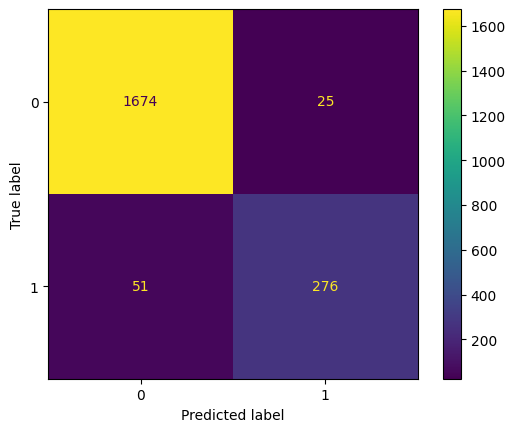

In [149]:
from sklearn.metrics import ConfusionMatrixDisplay, precision_score

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

1. True Negative (1674)
Sebanyak 1674 pelanggan yang sebenarnya tidak churn berhasil diprediksi tidak churn oleh model. Ini menunjukkan bahwa model cukup baik dalam mengenali pelanggan yang akan tetap bertahan.

2. False Positive (25)
Sebanyak 25 pelanggan yang sebenarnya tidak churn diprediksi sebagai churn. Artinya model mengira pelanggan tersebut berisiko churn padahal sebenarnya tidak. Dampaknya secara bisnis biasanya hanya berupa biaya retensi yang tidak perlu (misalnya diberi promo padahal tidak akan pergi).

3. False Negative (51)
Sebanyak 51 pelanggan yang sebenarnya churn diprediksi tidak churn. Ini adalah kesalahan yang lebih berisiko karena perusahaan gagal mendeteksi pelanggan yang akan pergi, sehingga tidak ada strategi retensi yang dilakukan dan potensi revenue bisa hilang.

4. True Positive (276)
Sebanyak 276 pelanggan yang benar-benar churn berhasil dideteksi oleh model. Ini berarti model mampu mengidentifikasi pelanggan yang berisiko tinggi sehingga perusahaan dapat melakukan tindakan pencegahan seperti memberikan promo atau meningkatkan layanan.

## b. Hitung minimal dua metrik tambahan (Precision, Recall, F1-score, atau ROC-AUC).


In [137]:
ROC = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)

print(f'nilai ROC-AUC dari model: {ROC}')
print(f'nilai precision dari model {precision}')

nilai ROC-AUC dari model: 0.9915438655226225
nilai precision dari model 0.9169435215946844


## c.Jelaskan implikasi masing-masing metrik terhadap risiko bisnis churn.


1. ROC-AUC (0.9915) menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam membedakan pelanggan yang akan churn dan yang tidak churn. Hal ini memungkinkan perusahaan mengidentifikasi pelanggan berisiko tinggi secara lebih akurat sehingga strategi retensi dapat difokuskan pada pelanggan yang benar-benar membutuhkan perhatian.

2. Precision (0.9169) menunjukkan bahwa sebagian besar pelanggan yang diprediksi churn memang benar-benar churn. Ini membantu perusahaan mengurangi kesalahan penargetan program retensi, sehingga biaya seperti promo atau insentif tidak banyak diberikan kepada pelanggan yang sebenarnya tidak berisiko churn.

## d. Alasan pemilihan model terbaik

Model dipilih karena menunjukkan performa evaluasi yang sangat baik dengan ROC-AUC yang sangat tinggi dan precision yang kuat. Hal ini menunjukkan bahwa model mampu mengidentifikasi pelanggan berisiko churn dengan akurat sekaligus menjaga efisiensi biaya retensi, sehingga memberikan manfaat yang signifikan bagi pengambilan keputusan bisnis.

# Analisis Interpretabilitas Model


## a. Identifikasi fitur-fitur yang paling berpengaruh terhadap churn.


In [146]:
feature_importance = pd.DataFrame({
    'feature' : X.columns,
    'importance' : model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)
feature_importance.head(10)

,feature,importance
14,total_trans_ct,0.211291
10,total_revolving_bal,0.143252
6,total_relationship_count,0.103942
15,total_ct_chng_q4_q1,0.056067
13,total_trans_amt,0.055499
1,gender,0.050298
9,credit_limit,0.044634
12,total_amt_chng_q4_q1,0.042094
0,customer_age,0.036428
7,months_inactive_12_mon,0.032103


## b. Gunakan metode interpretasi yang sesuai dengan model yang dipilih.

Interpretasi model dilakukan menggunakan feature importance dari model XGBoost. Metode ini digunakan karena XGBoost merupakan model berbasis tree ensemble yang dapat menunjukkan tingkat kontribusi setiap fitur dalam proses pengambilan keputusan model. Dengan melihat nilai feature importance, dapat diketahui fitur mana yang paling berpengaruh dalam memprediksi churn pelanggan.

## c. Bandingkan hasil interpretasi dengan temuan pada tahap EDA.

Hasil interpretasi menunjukkan bahwa fitur yang berkaitan dengan aktivitas transaksi dan hubungan pelanggan dengan layanan seperti total_trans_ct, total_revolving_bal, dan total_relationship_count memiliki pengaruh besar terhadap churn. Hal ini konsisten dengan hasil EDA sebelumnya yang menunjukkan bahwa pelanggan dengan aktivitas transaksi yang rendah atau perubahan transaksi yang menurun cenderung memiliki risiko churn yang lebih tinggi.

## d. Jelaskan implikasi bisnis dari faktor-faktor yang ditemukan.
Faktor-faktor tersebut menunjukkan bahwa perilaku transaksi dan tingkat keterlibatan pelanggan menjadi indikator penting dalam memprediksi churn. Oleh karena itu, perusahaan dapat memfokuskan strategi retensi pada pelanggan yang menunjukkan penurunan aktivitas transaksi atau interaksi layanan, misalnya dengan memberikan penawaran khusus, program loyalitas, atau peningkatan layanan untuk mendorong pelanggan tetap aktif menggunakan produk perusahaan.

# simulasi dampak bisnis

## a. Identifikasi customer berisiko tinggi berdasarkan hasil prediksi model.


Customer berisiko tinggi diidentifikasi berdasarkan hasil prediksi model churn. Pelanggan yang diprediksi churn oleh model dianggap sebagai pelanggan dengan risiko tinggi karena model memperkirakan bahwa mereka memiliki kemungkinan besar untuk berhenti menggunakan layanan.

Berdasarkan confusion matrix model:

| Actual / Predicted | Not Churn | Churn |
|--------------------|-----------|-------|
| Not Churn          | 1674      | 25    |
| Churn              | 51        | 276   |

Model berhasil mengidentifikasi 276 pelanggan churn (True Positive) yang dapat menjadi target utama dalam strategi retensi.

## b. sumsi biaya retensi per customer

Dalam simulasi ini digunakan asumsi bahwa perusahaan mengeluarkan biaya retensi sebesar 200 per customer. Biaya ini dapat berupa diskon, promo, cashback, atau peningkatan layanan yang bertujuan untuk mempertahankan pelanggan agar tidak churn.

## c. Potensi revenue yang dapat diselamatkan

Berdasarkan data, rata-rata revenue yang dihasilkan oleh pelanggan churn adalah 3095.03.

Jika model digunakan, maka pelanggan churn yang berhasil terdeteksi adalah 276 pelanggan.

Potensi revenue yang dapat diselamatkan:

276 × 3095.03 ≈ 854,226

Total biaya retensi:

276 × 200 = 55,200

Sehingga estimasi net revenue yang dapat diselamatkan adalah:

854,226 - 55,200 ≈ 799,026

## d. Perbandingan skenario bisnis

- Tanpa model

Tanpa menggunakan model churn, perusahaan tidak dapat mengidentifikasi pelanggan yang akan churn. Berdasarkan data terdapat 327 pelanggan churn, sehingga potensi revenue yang hilang adalah:

327 × 3095.03 ≈ 1,012,073

- Dengan model

Dengan menggunakan model churn, perusahaan dapat mendeteksi 276 pelanggan yang berpotensi churn dan melakukan strategi retensi kepada mereka. Dengan demikian perusahaan berpotensi menyelamatkan sekitar 854 ribu revenue, dengan biaya retensi sekitar 55 ribu.

#  Executive Summary

Analisis ini bertujuan untuk mengidentifikasi pelanggan yang berpotensi churn dan memahami faktor utama yang mempengaruhinya. Hasil analisis menunjukkan bahwa faktor yang paling berpengaruh terhadap churn berkaitan dengan aktivitas transaksi dan keterlibatan pelanggan, seperti total_trans_ct, total_revolving_bal, dan total_relationship_count. Pelanggan dengan aktivitas transaksi yang menurun cenderung memiliki risiko churn yang lebih tinggi. maka
Berdasarkan evaluasi model menggunakan metrik Recall, F1-score, dan ROC-AUC, model XGBoost dipilih sebagai model terbaik karena menunjukkan performa paling baik dengan ROC-AUC sebesar 0.9915 dan precision sebesar 0.9169. Hal ini menunjukkan bahwa model mampu membedakan pelanggan churn dan non-churn dengan sangat baik.oleh karena itu
Simulasi dampak bisnis menunjukkan bahwa tanpa model perusahaan berpotensi kehilangan sekitar 1.01 juta revenue, sementara dengan menggunakan model churn perusahaan berpotensi menyelamatkan sekitar 854 ribu revenue melalui strategi retensi yang lebih tepat sasaran. Oleh karena itu, perusahaan disarankan memprioritaskan strategi retensi pada pelanggan dengan aktivitas transaksi yang menurun untuk mengurangi risiko churn dan menjaga pendapatan perusahaan.